# Creator Monetization Predictor — Project Overview

## Objective
Predict the monetization potential of makeup YouTube Shorts creators using engagement and content signals as a proxy for short-form video platform creator monetization strategies.

## Data
- ~1,983 YouTube Shorts scraped via YouTube Data API v3
- Focused on makeup content (tutorials, GRWM, dupes, glam, etc.)
- Covers 2022–2025

## EDA Highlights

### Distribution & Data Quality
- Log transformed views, likes, comments, subscriber count, total channel views, total videos, and view velocity to address heavy right skew
- Removed years 2018, 2020, 2021, and 2026 to retain only full years of Shorts data (2022–2025)
- Flagged 289 viral videos (14.6%) using IQR method — videos exceeding the upper fence of view distribution
- engagement_rate and like_rate are highly correlated (0.99) — near identical signals
- subscriber_count and total_channel_views are strongly correlated (0.88) — multicollinearity risk for modeling

### Time Patterns
- Upload activity peaks between 14–16 UTC (6–8am PST / 9–11am EST) — creators timing for US morning audiences
- Evening uploads (18–24 UTC) have the highest average engagement rate, morning (6–12 UTC) the lowest
- Tuesday and Wednesday see the most uploads; weekends are slightly lower
- Q2 (April/May) dominates upload volume — peak beauty content season (spring looks, prom, festival glam)
- Engagement rate has declined year over year from 2022 → 2025 as platform competition increases

### Content Analysis
- 15 content types classified from video titles including Tutorial, GRWM, Dupe/Affordable, Glam, Beginner, Routine, Transformation, Natural, K-Beauty/KPop, Hack/Tip, Everyday/School, Haul/Shopping, Skin/Coverage, Transition/Ranking, and Other
- Routine and Dupe/Affordable content types drive the highest average engagement rates
- Haul/Shopping and Hack/Tip content have the lowest average engagement rates
- ~20% of videos fell into "Other" — titles without clear content-type keywords

### Video Length
- 16–30s is the most common duration bucket
- Longer Shorts (46–60s) drive significantly higher engagement than shorter ones (0–15s)
- Clear positive trend: engagement rate increases as video length increases

### Subscriber Tiers
- Dataset is well distributed across all tiers from Unknown (<1K) to Mega (1M+)
- Mega (1M+) and Macro (300K–1M) creators have the highest average engagement rates (~3.8%)
- Smaller tiers (Unknown, Nano) have noticeably lower engagement rates (~2.1–2.7%)
- Contradicts the common assumption that smaller creators have higher engagement in makeup niche

### Outliers
- Log views has a wide IQR suggesting high variance in video performance even within the dataset
- Engagement rate has several extreme outliers above 0.125 — likely viral spikes from small channels
- Log subscriber count shows wide spread indicating diverse creator sizes captured

## Modeling Plan

### 1. Regression — Predict Engagement Rate
- Predict the actual engagement rate value for a Short
- Identify which content and channel features drive engagement
- Models: Linear Regression, Random Forest, XGBoost

### 2. Classification — Predict High Monetization Potential
- Binary label: high potential = above median engagement rate AND above median views
- Predict whether a Short will be high or low monetization potential
- Models: Logistic Regression, Random Forest, XGBoost
- Evaluate with accuracy, precision, recall, F1, confusion matrix

### 3. A/B Test Simulation
- Test whether evening uploads significantly outperform morning uploads in engagement
- Use Mann-Whitney U test for statistical significance

## Business Framing
Insights are framed as actionable recommendations for short-form video monetization teams — identifying what content signals predict creator earning potential within beauty and makeup niches on short-form video platforms.

# **Part I:** Regression - Predicting Engagement Rate

## 1. Load and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, roc_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report)
from xgboost import XGBRegressor, XGBClassifier

In [2]:
df = pd.read_csv('data/makeup_shorts_clean.csv')
print(df.shape)
df.head()

(1983, 24)


,video_id,channel_id,published_at,year,quarter,month,day_of_week,hour,hour_bucket,days_since_upload,...,log_subscriber_count,log_total_channel_views,log_total_videos,log_views,log_likes,log_comments,log_view_velocity,engagement_rate,like_rate,is_viral
0,3punW8R-OBQ,UC73sF-7Ihcs1HpnXEEXZ2ew,2022-06-18 01:41:08+00:00,2022,2,June,Saturday,1,Night (0-6),1416,...,16.213406,23.261486,8.370547,15.789052,12.501990,7.988204,8.533657,0.0378,0.0374,0
1,5RFG4hVEW0Q,UC3ocVSGRoapPsbG8QrFX5kA,2025-08-16 16:30:02+00:00,2025,3,August,Saturday,16,Afternoon (12-18),260,...,13.475835,21.126143,7.606884,14.031835,10.697769,5.093750,8.471358,0.0358,0.0356,0
2,hbstT1uZpQw,UCpwlclcyceJHtihaaysgsbg,2024-10-30 19:50:33+00:00,2024,4,October,Wednesday,19,Evening (18-24),550,...,11.589896,16.694826,6.261492,14.143022,10.056337,5.262690,7.833481,0.0169,0.0168,0
3,YejAxKQ3Dwg,UCdzHDmZaxystjVTwLQumPiw,2024-08-01 00:05:18+00:00,2024,3,August,Thursday,0,Night (0-6),641,...,14.200773,20.787504,5.811141,16.456013,12.182921,7.439559,9.993032,0.0141,0.0139,1
4,gyDRYoz9yAw,UCUlFo1jlYURiV2_ldmeP2Ag,2024-09-24 02:08:45+00:00,2024,3,September,Tuesday,2,Night (0-6),587,...,14.173185,19.756277,6.018593,15.180473,0.000000,7.115582,8.805600,0.0003,0.0000,0


## 2. Define X and y for Regression

In [3]:
y = df['engagement_rate']

In [4]:
drop_cols = [
    'engagement_rate',     # target
    'like_rate',           # leakage — direct component of engagement rate
    'log_views',           # leakage — views are part of engagement rate formula
    'log_likes',           # leakage
    'log_comments',        # leakage
    'is_viral',            # leakage — derived from views
    'video_id',            # identifier
    'channel_id',          # identifier
    'published_at',        # replaced by extracted time features
    'hour',                # bucketed into hour_bucket
    'duration_seconds',    # bucketed into duraction_buvker
    'quarter'              # overlaps with month
]

In [5]:
X = df.drop(columns=drop_cols)

In [6]:
print(f"Target shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"\nFeatures going into model:")
print(X.columns.tolist())

Target shape: (1983,)
Features shape: (1983, 12)

Features going into model:
['year', 'month', 'day_of_week', 'hour_bucket', 'days_since_upload', 'duration_bucket', 'content_type', 'subscriber_tier', 'log_subscriber_count', 'log_total_channel_views', 'log_total_videos', 'log_view_velocity']


## 3. Encode categoricals

In [7]:
# ordinal encode subscriber_tier (has natural order)
tier_order = ['Unknown (<1K)', 'Nano (1K-5K)', 'Micro (5K-50K)',
              'Mid-Tier (50K-300K)', 'Macro (300K-1M)', 'Mega (1M+)']

In [8]:
ordinal_enc = OrdinalEncoder(categories=[tier_order])
X['subscriber_tier_encoded'] = ordinal_enc.fit_transform(X[['subscriber_tier']])
X = X.drop(columns=['subscriber_tier'])

In [9]:
# one-hot encode categoricals
ohe_cols = ['month', 'day_of_week', 'hour_bucket', 'duration_bucket', 'content_type']
X = pd.get_dummies(X, columns=ohe_cols, drop_first=True, dtype=float)


In [10]:
print(f"Features shape after encoding: {X.shape}")
print(f"\nFeature names:")
print(X.columns.tolist())

Features shape after encoding: (1983, 44)

Feature names:
['year', 'days_since_upload', 'log_subscriber_count', 'log_total_channel_views', 'log_total_videos', 'log_view_velocity', 'subscriber_tier_encoded', 'month_August', 'month_December', 'month_February', 'month_January', 'month_July', 'month_June', 'month_March', 'month_May', 'month_November', 'month_October', 'month_September', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'hour_bucket_Evening (18-24)', 'hour_bucket_Morning (6-12)', 'hour_bucket_Night (0-6)', 'duration_bucket_16-30s', 'duration_bucket_31-45s', 'duration_bucket_46-60s', 'content_type_Dupe/Affordable', 'content_type_Everyday/School', 'content_type_GRWM', 'content_type_Glam', 'content_type_Hack/Tip', 'content_type_Haul/Shopping', 'content_type_K-Beauty/KPop', 'content_type_Natural', 'content_type_Other', 'content_type_Routine', 'content_type_Skin/Coverage', 'content_type_Tra

## 4. Train/Test Split for Regression

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(f"Training set:   X={X_train.shape}, y={y_train.shape}")
print(f"Test set:       X={X_test.shape},  y={y_test.shape}")
print(f"\nTrain engagement rate mean: {y_train.mean():.4f}")
print(f"Test engagement rate mean:  {y_test.mean():.4f}")

Training set:   X=(1586, 44), y=(1586,)
Test set:       X=(397, 44),  y=(397,)

Train engagement rate mean: 0.0316
Test engagement rate mean:  0.0332


## 5. Scaling numerical features

In [13]:
numerical_cols = ['days_since_upload', 'log_subscriber_count',
                  'log_total_channel_views', 'log_total_videos',
                  'log_view_velocity', 'year', 'subscriber_tier_encoded']

scaler = StandardScaler()

In [14]:
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [15]:
print(f"\nTrain mean after scaling:")
print(X_train[numerical_cols].mean().round(4))
print(f"\nTrain std after scaling:")
print(X_train[numerical_cols].std().round(4))


Train mean after scaling:
days_since_upload          0.0
log_subscriber_count       0.0
log_total_channel_views   -0.0
log_total_videos          -0.0
log_view_velocity          0.0
year                      -0.0
subscriber_tier_encoded    0.0
dtype: float64

Train std after scaling:
days_since_upload          1.0003
log_subscriber_count       1.0003
log_total_channel_views    1.0003
log_total_videos           1.0003
log_view_velocity          1.0003
year                       1.0003
subscriber_tier_encoded    1.0003
dtype: float64


## 6. Train Models

## **Linear Regression - Baseline**

In [16]:
X_train_sm = sm.add_constant(X_train)

lr_sm = sm.OLS(y_train.astype(float), X_train_sm).fit()
print(lr_sm.summary())

                            OLS Regression Results                            
Dep. Variable:        engagement_rate   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     21.31
Date:                Mon, 04 May 2026   Prob (F-statistic):          1.40e-127
Time:                        02:20:02   Log-Likelihood:                 4084.9
No. Observations:                1586   AIC:                            -8080.
Df Residuals:                    1541   BIC:                            -7838.
Df Model:                          44                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [17]:
X_test_sm = sm.add_constant(X_test.astype(float))
y_pred_lr_test = lr_sm.predict(X_test_sm)

print("Linear Regression — Test Set Performance:")
print(f"R²:   {r2_score(y_test, y_pred_lr_test):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_lr_test):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr_test):.4f}")

Linear Regression — Test Set Performance:
R²:   0.3640
RMSE: 0.0181
MAE:  0.0137


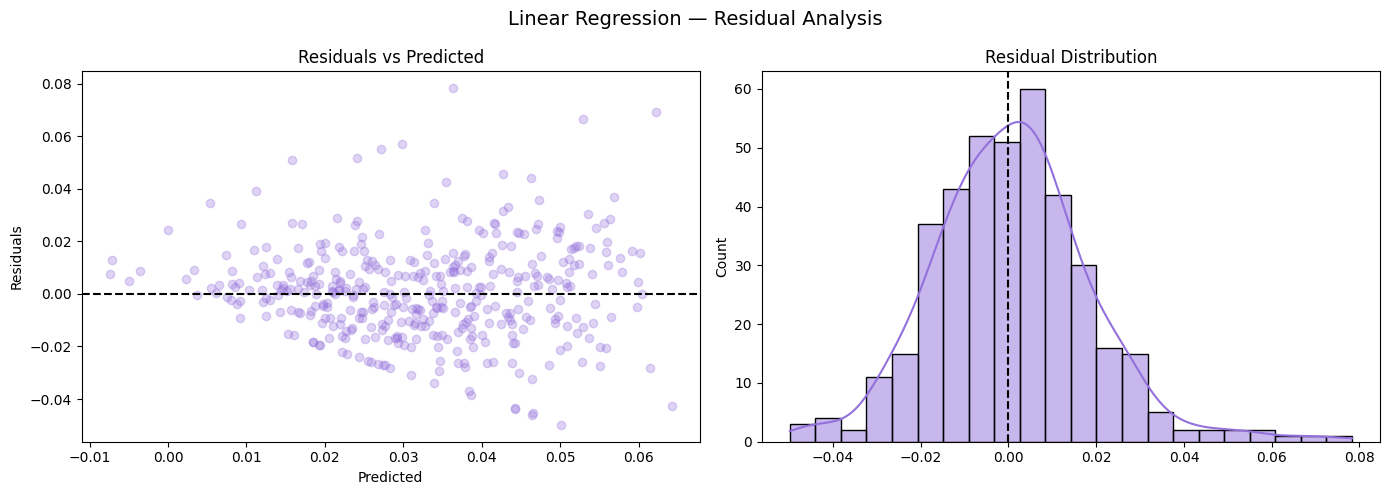

In [18]:
residuals = y_test - y_pred_lr_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals vs predicted
axes[0].scatter(y_pred_lr_test, residuals, alpha=0.3, color='mediumpurple')
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# residual distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='mediumpurple')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution')

plt.suptitle('Linear Regression — Residual Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## **Linear Regression Results**

### Model Performance
| Metric | LR Model (44 features) |
|---|---|
| R² | 0.378 | 
| Adjusted R² | 0.361 | 
| Features | 44 |

### Test Set Performance
| Metric | Score |
|---|---|
| R² | 0.364 |
| RMSE | 0.0181 |
| MAE | 0.0137 |

### Key Predictors
**Positive:** `duration_bucket_46-60s`, `duration_bucket_31-45s`, `log_subscriber_count`, `subscriber_tier_encoded`, `hour_bucket_Evening`, `content_type_Routine`

**Negative:** `log_view_velocity`, `log_total_channel_views`, `log_total_videos`, `content_type_Hack/Tip`, `hour_bucket_Morning`

**Not significant:** month variables, most content types, `year`, `days_since_upload`

### Residual Analysis
- **Heteroscedasticity detected** — residuals fan out as predicted values increase, violating a core linear regression assumption
- **Non-normal residuals** — right-skewed distribution confirms model consistently underestimates high engagement videos
- Model struggles to capture high engagement rate videos where unobservable content quality factors dominate

### Limitations & Conclusion
- R² of 0.364 on test set is consistent with social media engagement prediction benchmarks
- Residual patterns confirm non-linear relationships exist between features and engagement rate that Linear Regression cannot capture

## **Random Forest (with GridSearchCV)**

In [19]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt', 'log2']
}

In [20]:
rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [21]:
rf = rf_grid.best_estimator_

print("Best Parameters:")
for param, value in rf_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best CV R²:  {rf_grid.best_score_:.4f}")
print(f"   OOB Score:   {rf.oob_score_:.4f}")

Best Parameters:
   max_depth: 20
   max_features: sqrt
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 300

   Best CV R²:  0.3946
   OOB Score:   0.4008


In [22]:
rf_cv_rmse = cross_val_score(rf, X_train, y_train, cv=5,
                              scoring='neg_root_mean_squared_error')
rf_cv_mae  = cross_val_score(rf, X_train, y_train, cv=5,
                              scoring='neg_mean_absolute_error')

print(f"CV RMSE: {(-rf_cv_rmse).mean():.4f} ± {(-rf_cv_rmse).std():.4f}")
print(f"CV MAE:  {(-rf_cv_mae).mean():.4f} ± {(-rf_cv_mae).std():.4f}")

CV RMSE: 0.0181 ± 0.0011
CV MAE:  0.0130 ± 0.0008


In [23]:
y_pred_rf = rf.predict(X_test)

print(f"Random Forest — Test Set Performance:")
print(f"R²:   {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_rf):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}")

Random Forest — Test Set Performance:
R²:   0.4389
RMSE: 0.0170
MAE:  0.0130


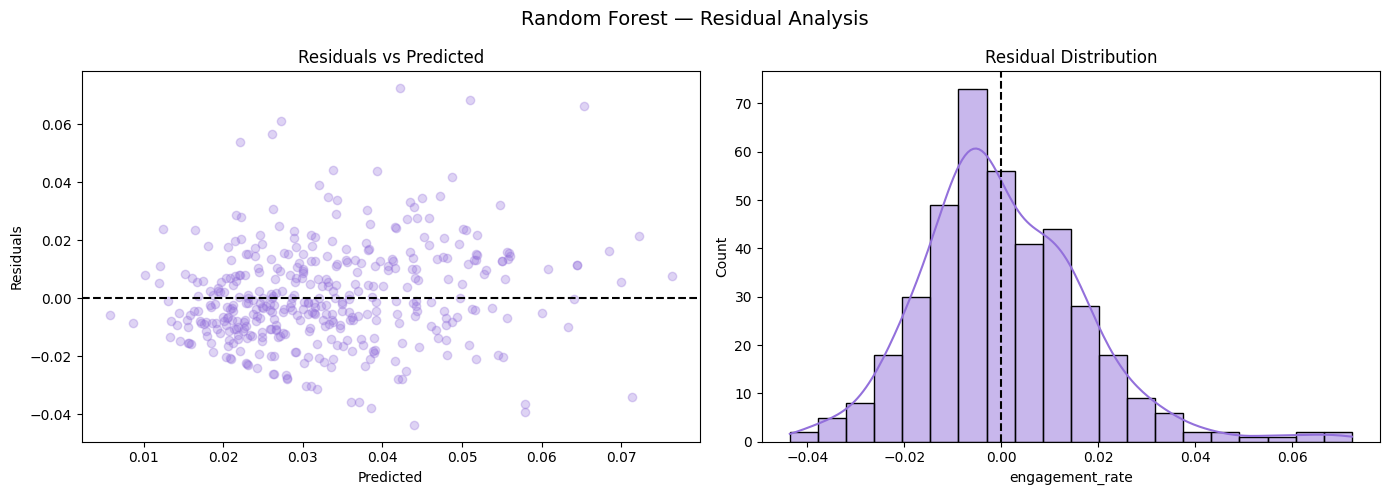

In [24]:
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals vs predicted
axes[0].scatter(y_pred_rf, residuals_rf, alpha=0.3, color='mediumpurple')
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# residual distribution
sns.histplot(residuals_rf, kde=True, ax=axes[1], color='mediumpurple')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution')

plt.suptitle('Random Forest — Residual Analysis', fontsize=14)
plt.tight_layout()
plt.show()

Top 15 Feature Importances:
                         feature  importance
5              log_view_velocity    0.154121
1              days_since_upload    0.113301
2           log_subscriber_count    0.099939
3        log_total_channel_views    0.084947
4               log_total_videos    0.084567
29        duration_bucket_46-60s    0.060526
6        subscriber_tier_encoded    0.046652
0                           year    0.041770
28        duration_bucket_31-45s    0.023783
24   hour_bucket_Evening (18-24)    0.016633
27        duration_bucket_16-30s    0.016067
25    hour_bucket_Morning (6-12)    0.013745
30  content_type_Dupe/Affordable    0.013683
38            content_type_Other    0.012650
33             content_type_Glam    0.012336


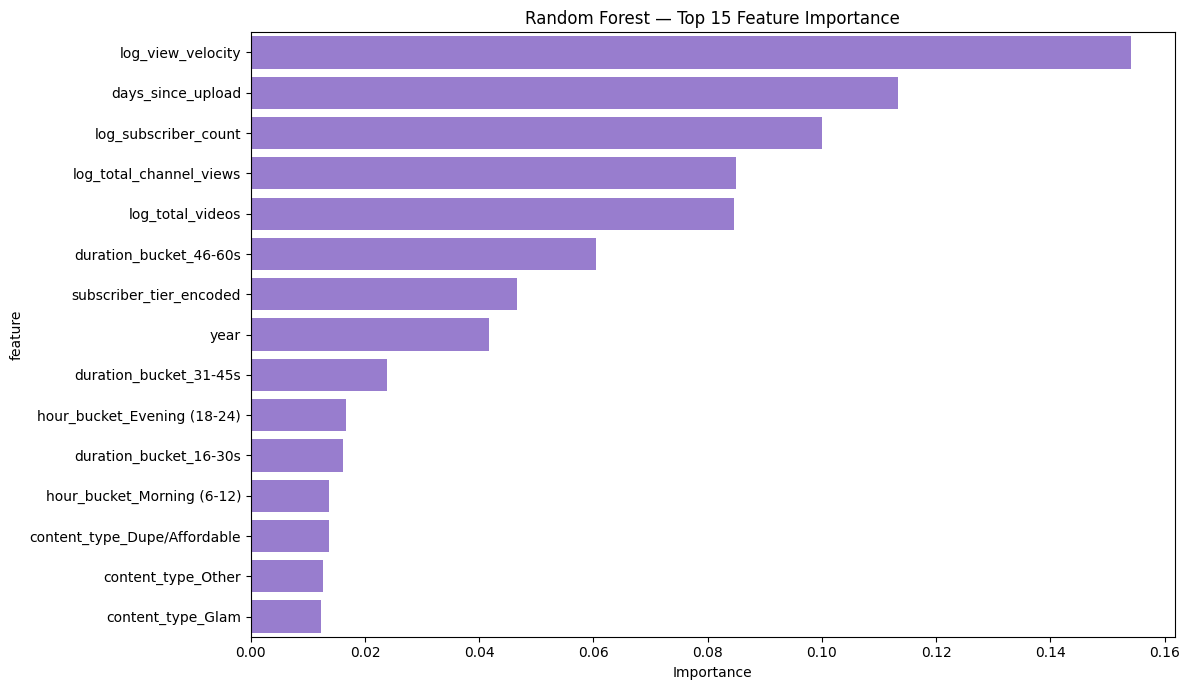

In [25]:
rf_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("Top 15 Feature Importances:")
print(rf_importance.to_string())

plt.figure(figsize=(12, 7))
sns.barplot(data=rf_importance, x='importance', y='feature', color='mediumpurple')
plt.title('Random Forest — Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [26]:
features_to_plot = [
    'log_view_velocity',
    'days_since_upload',
    'log_subscriber_count',
    'log_total_channel_views',
    'log_total_videos',
    'subscriber_tier_encoded'
]

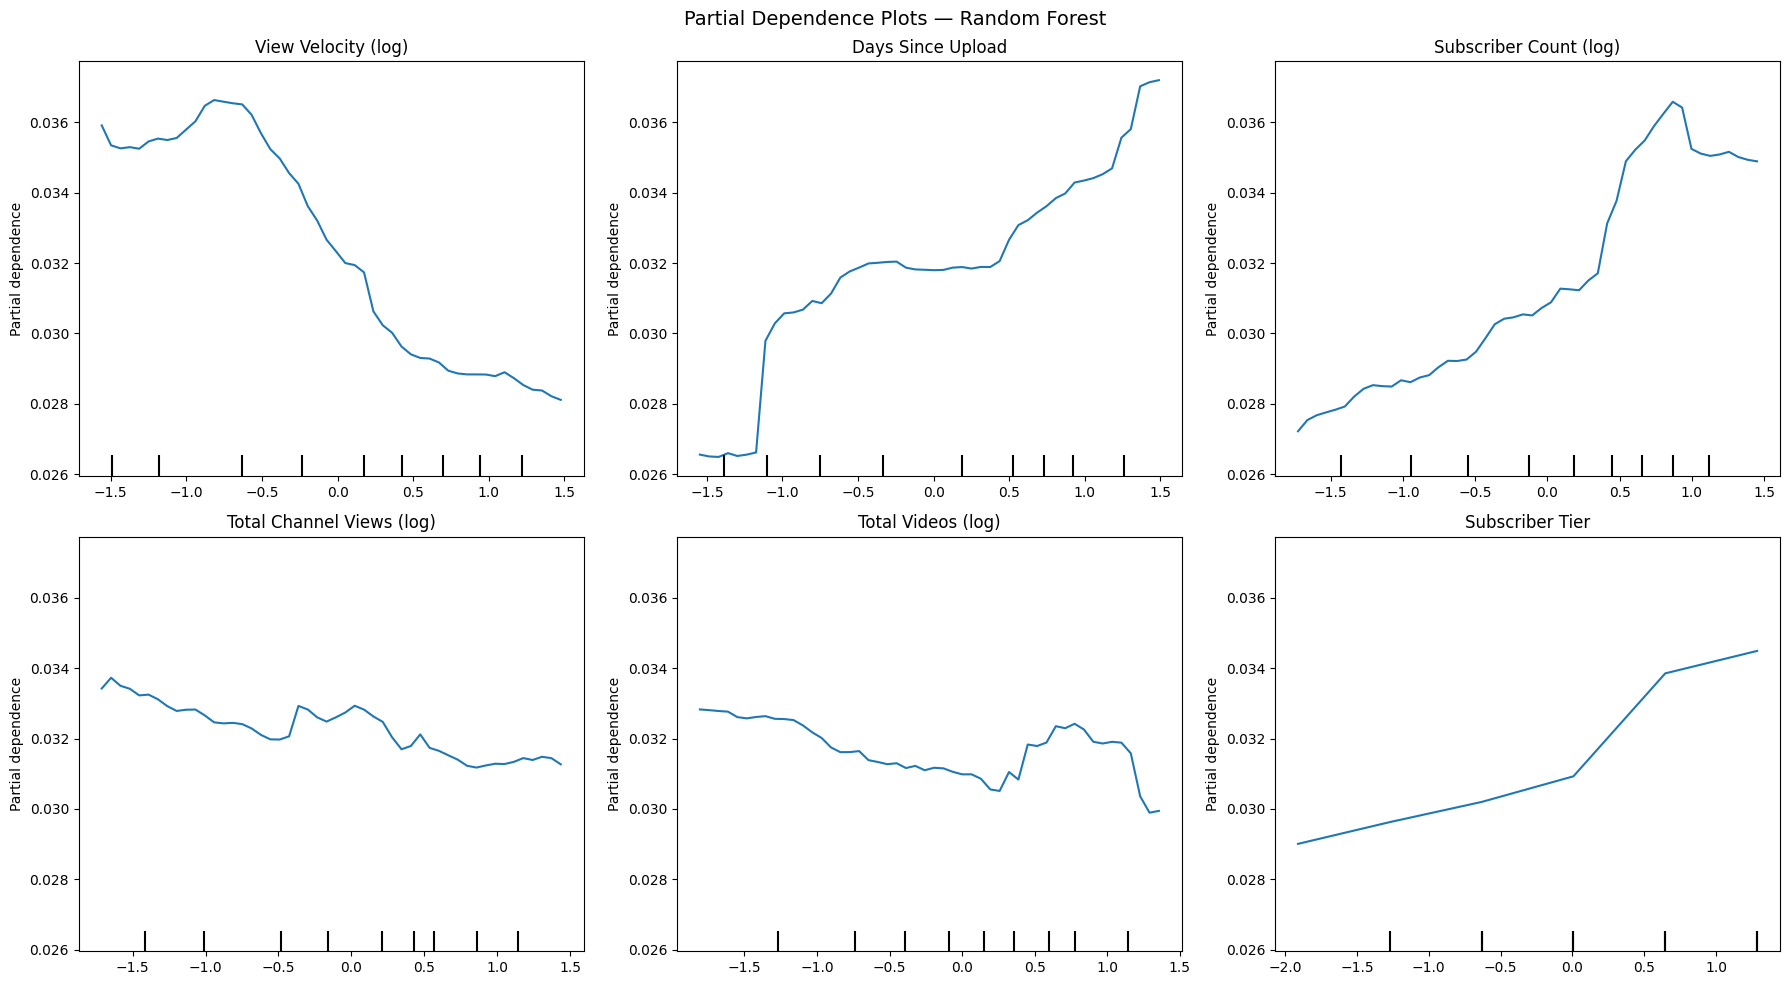

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

display = PartialDependenceDisplay.from_estimator(
    rf, X_train, features_to_plot,
    ax=axes[:len(features_to_plot)],
    grid_resolution=50
)

titles = ['View Velocity (log)', 'Days Since Upload',
          'Subscriber Count (log)', 'Total Channel Views (log)',
          'Total Videos (log)', 'Subscriber Tier']

for i, ax in enumerate(axes[:len(features_to_plot)]):
    ax.set_title(titles[i])
    ax.set_xlabel('')

plt.suptitle('Partial Dependence Plots — Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

## **Random Forest Results**

### Best Parameters (GridSearchCV — 72 combinations, 5-fold CV)
| Parameter | Value |
|---|---|
| n_estimators | 300 |
| max_depth | 20 |
| max_features | sqrt |
| min_samples_split | 2 |
| min_samples_leaf | 1 |

### Model Performance
| Metric | CV (GridSearch) | OOB | Test Set |
|---|---|---|---|
| R² | 0.3946 | 0.4008 | 0.4389 |
| RMSE | 0.0181 ± 0.0011 | — | 0.0170 |
| MAE | 0.0130 ± 0.0008 | — | 0.0130 |
- CV R² ≈ OOB Score (0.3946 vs 0.4008) — model is stable and not overfitting. 
- CV RMSE (0.0181) and MAE (0.0130) are consistent with test set performance (RMSE: 0.0170, MAE: 0.0130) confirming the model generalizes well to unseen data. 
- Test set R² of 0.4389 outperforms Linear Regression (0.364), confirming RF captures non-linear relationships in engagement rate.

### Top Features (by importance)
1. `log_view_velocity` — most influential, higher velocity = lower engagement rate
2. `days_since_upload` — older videos accumulate higher engagement over time
3. `log_subscriber_count` — larger channels drive more engagement
4. `log_total_channel_views` — slightly negative effect
5. `log_total_videos` — more prolific channels have lower per-video engagement
6. `duration_bucket_46-60s` — strongest content signal

### Partial Dependence Analysis
- **View Velocity** — clear negative relationship, viral-speed videos trade reach for depth
- **Days Since Upload** — positive trend, engagement accumulates over time
- **Subscriber Count** — peaks at mid-large channels, slight drop for mega channels
- **Subscriber Tier** — clear positive trend confirming ordinal encoding was appropriate

### Residual Analysis
- Reduced heteroscedasticity compared to Linear Regression
- Residuals more centered around 0
- Still underestimates viral outliers — motivates XGBoost

### vs Linear Regression
| Metric | Linear Regression | Random Forest | Improvement |
|---|---|---|---|
| R² | 0.364 | 0.439 | +0.075 |
| RMSE | 0.0181 | 0.0170 | -0.0011 |
| MAE | 0.0137 | 0.0130 | -0.0007 |

## **XGBoost (with GridSearchCV)**

In [28]:
param_grid_xgb = {
    'n_estimators':      [100, 200, 300],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [3, 5, 7],
    'subsample':         [0.8, 1.0],
    'colsample_bytree':  [0.8, 1.0]
}

In [29]:
xgb_grid = GridSearchCV(
    XGBRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [30]:
xgb = xgb_grid.best_estimator_

print("Best Parameters:")
for param, value in xgb_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best CV R²: {xgb_grid.best_score_:.4f}")

Best Parameters:
   colsample_bytree: 0.8
   learning_rate: 0.1
   max_depth: 5
   n_estimators: 100
   subsample: 0.8

   Best CV R²: 0.4270


In [31]:
xgb_cv_rmse = cross_val_score(xgb, X_train, y_train, cv=5,
                               scoring='neg_root_mean_squared_error')
xgb_cv_mae  = cross_val_score(xgb, X_train, y_train, cv=5,
                               scoring='neg_mean_absolute_error')

print(f"CV RMSE: {(-xgb_cv_rmse).mean():.4f} ± {(-xgb_cv_rmse).std():.4f}")
print(f"CV MAE:  {(-xgb_cv_mae).mean():.4f} ± {(-xgb_cv_mae).std():.4f}")

CV RMSE: 0.0176 ± 0.0010
CV MAE:  0.0126 ± 0.0009


In [32]:
y_pred_xgb = xgb.predict(X_test)

print("XGBoost — Test Set Performance:")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred_xgb):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}")

XGBoost — Test Set Performance:
R²:   0.4428
RMSE: 0.0170
MAE:  0.0128


Top 15 Feature Importances:
                        feature  importance
29       duration_bucket_46-60s    0.203078
28       duration_bucket_31-45s    0.083054
5             log_view_velocity    0.042640
27       duration_bucket_16-30s    0.041048
34        content_type_Hack/Tip    0.039711
2          log_subscriber_count    0.031580
25   hour_bucket_Morning (6-12)    0.029355
1             days_since_upload    0.027321
39         content_type_Routine    0.024713
6       subscriber_tier_encoded    0.022536
24  hour_bucket_Evening (18-24)    0.021831
3       log_total_channel_views    0.021606
12                   month_June    0.021223
41  content_type_Transformation    0.021169
33            content_type_Glam    0.020923


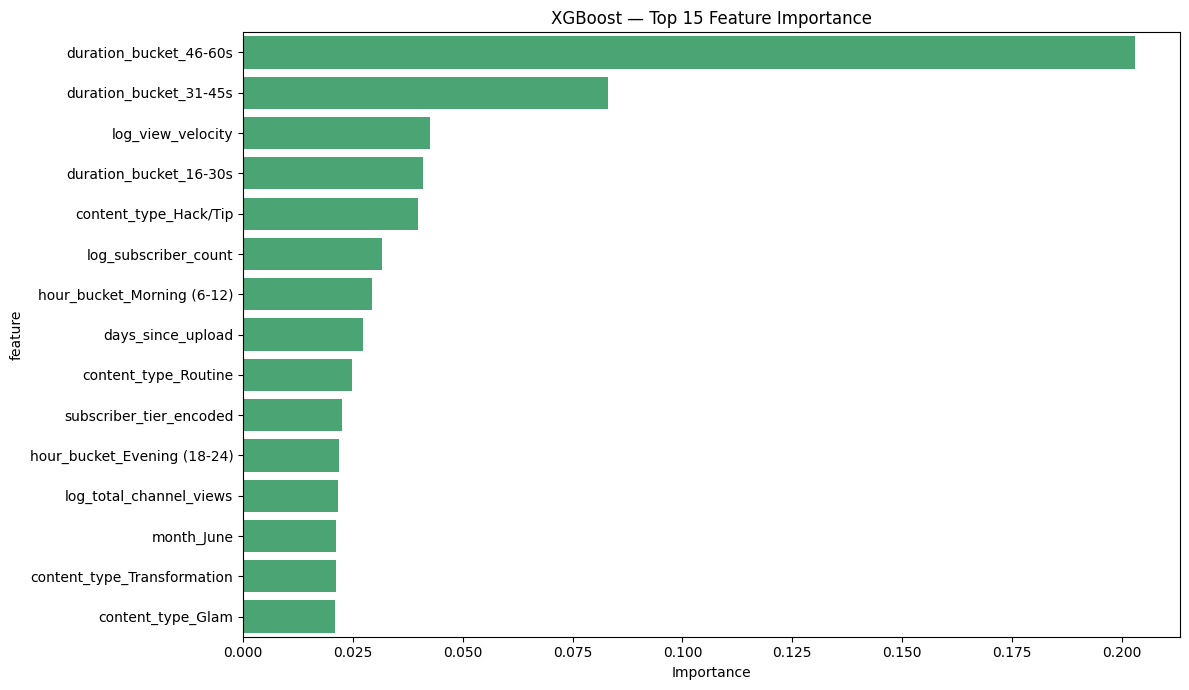

In [33]:
xgb_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print("Top 15 Feature Importances:")
print(xgb_importance.to_string())

plt.figure(figsize=(12, 7))
sns.barplot(data=xgb_importance, x='importance', y='feature', color='mediumseagreen')
plt.title('XGBoost — Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [34]:
features_to_plot = [
    'log_view_velocity',
    'log_subscriber_count',
    'days_since_upload',
    'log_total_channel_views',
    'subscriber_tier_encoded',
    'content_type_Hack/Tip'
]

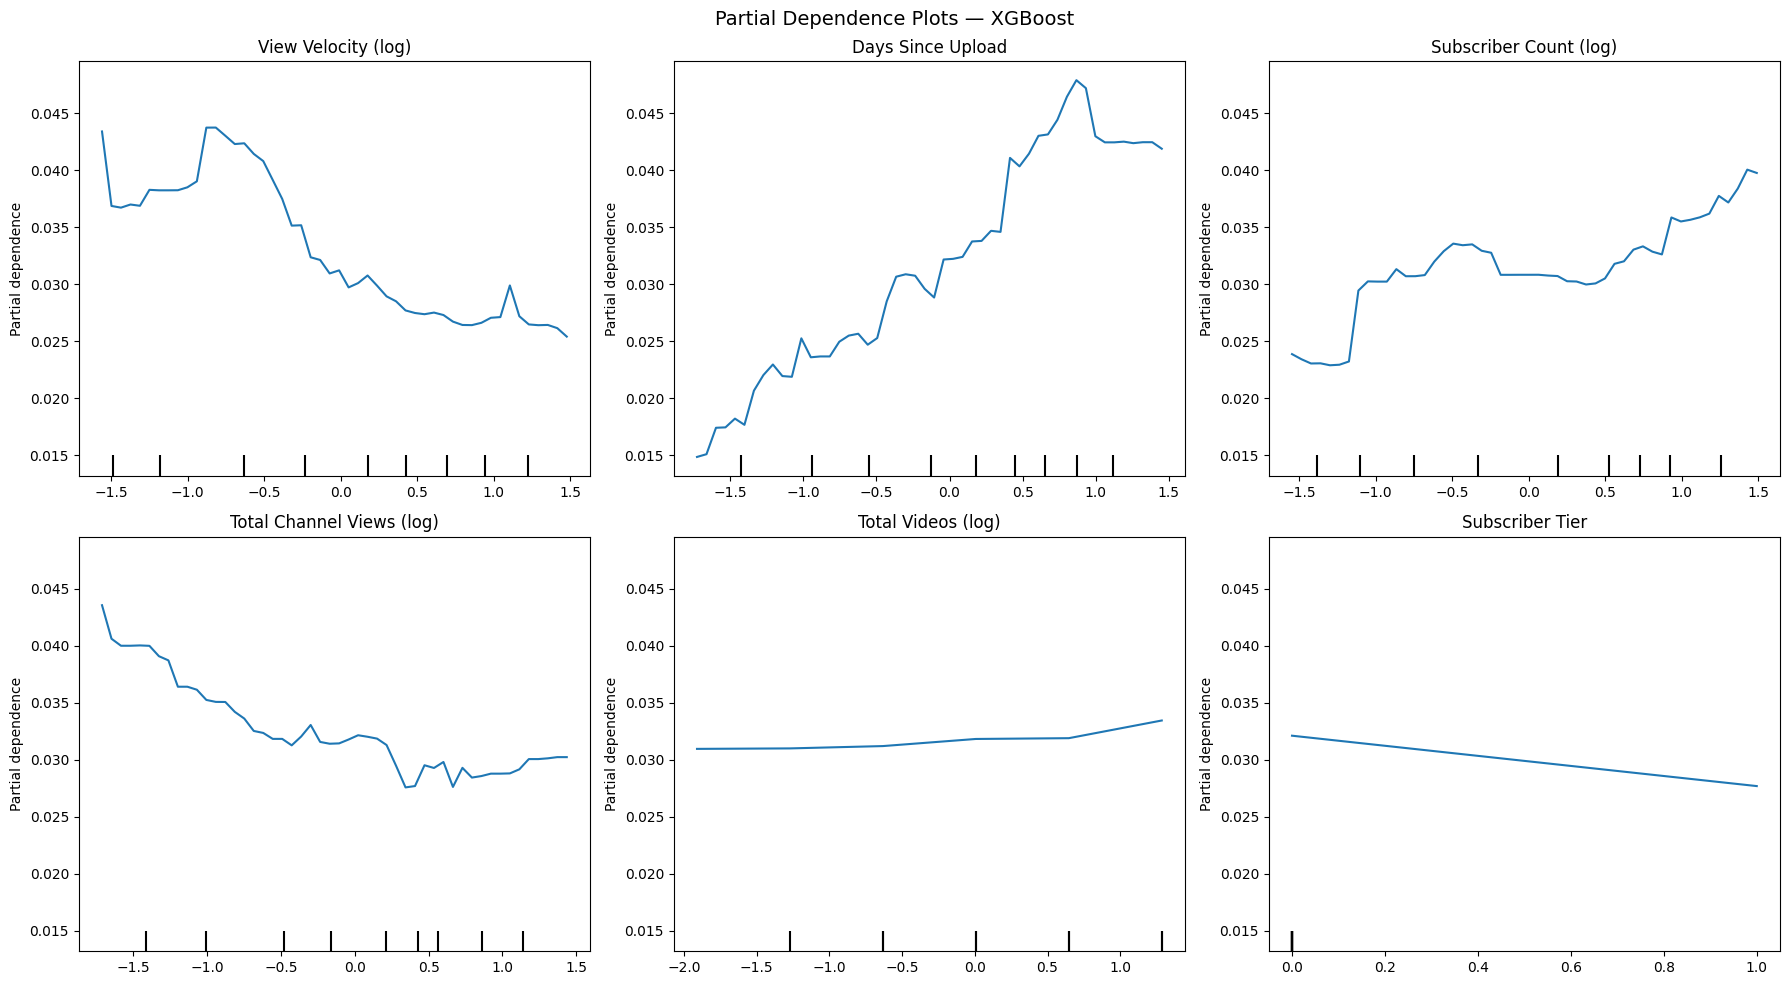

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

display = PartialDependenceDisplay.from_estimator(
    xgb, X_train, features_to_plot,
    ax=axes[:len(features_to_plot)],
    grid_resolution=50
)

titles = ['View Velocity (log)', 'Days Since Upload',
          'Subscriber Count (log)', 'Total Channel Views (log)',
          'Total Videos (log)', 'Subscriber Tier']

for i, ax in enumerate(axes[:len(features_to_plot)]):
    ax.set_title(titles[i])
    ax.set_xlabel('')

plt.suptitle('Partial Dependence Plots — XGBoost', fontsize=14)
plt.tight_layout()
plt.show()

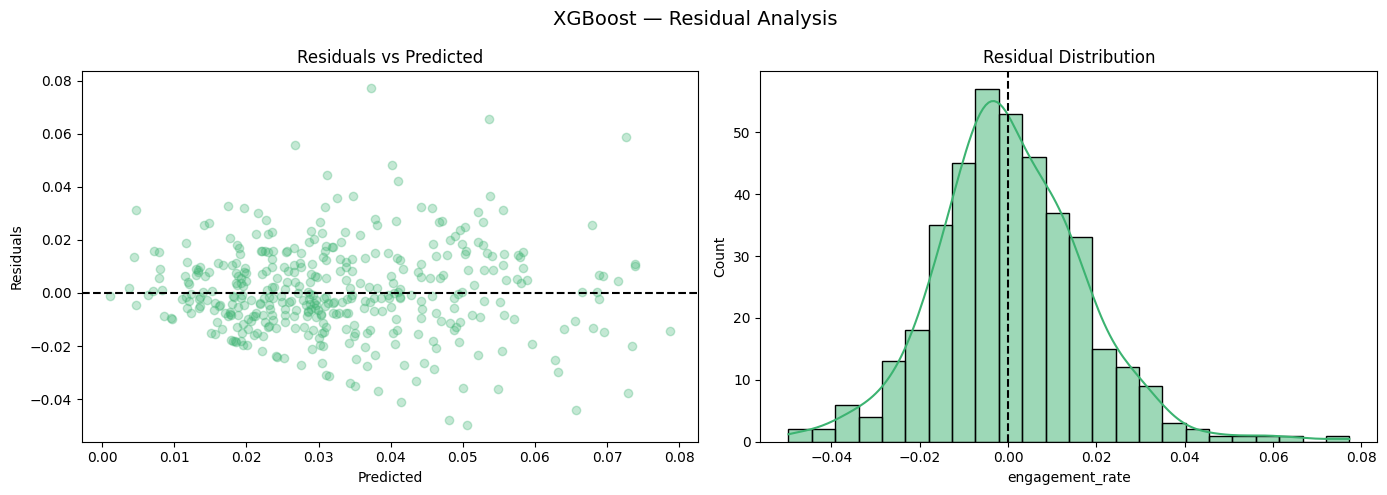

In [36]:
residuals_xgb = y_test - y_pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_xgb, residuals_xgb, alpha=0.3, color='mediumseagreen')
axes[0].axhline(y=0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

sns.histplot(residuals_xgb, kde=True, ax=axes[1], color='mediumseagreen')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution')

plt.suptitle('XGBoost — Residual Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## **XGBoost Results**

### Best Parameters (GridSearchCV — 108 combinations, 5-fold CV)
| Parameter | Value |
|---|---|
| n_estimators | 100 |
| learning_rate | 0.1 |
| max_depth | 5 |
| subsample | 0.8 |
| colsample_bytree | 0.8 |

### Model Performance
| Metric | CV (GridSearch) | Test Set |
|---|---|---|
| R² | 0.4270 | 0.4428 |
| RMSE | 0.0176 ± 0.0010 | 0.0170 |
| MAE | 0.0126 ± 0.0009 | 0.0128 |

CV and test metrics are consistent — model generalizes well with no overfitting.

### Top Features (by importance)
1. `duration_bucket_46-60s` — dominant signal, longest Shorts drive highest engagement
2. `duration_bucket_31-45s` — second strongest content signal
3. `log_view_velocity` — negative effect, viral speed trades reach for depth
4. `duration_bucket_16-30s` — moderate positive effect
5. `content_type_Hack/Tip` — strongest negative content type signal
6. `log_subscriber_count` — larger channels drive more engagement

**Key difference from RF:** XGBoost identifies video duration as the #1 driver while RF prioritized view velocity — both valid, reflecting different ways each model weights feature interactions.

### Partial Dependence Analysis
- **View Velocity** — clear negative trend consistent across all three models
- **Days Since Upload** — strong positive trend, peaks at mid-age videos
- **Subscriber Count** — positive trend, larger channels perform better
- **Total Channel Views** — clear negative relationship, established channels have lower per-video engagement
- **Subscriber Tier** — slightly negative in XGBoost vs positive in RF — notable disagreement between models

### Residual Analysis
- Most randomly scattered residuals of all three models
- Residual distribution most centered around 0
- Reduced right skew compared to LR and RF
- Best overall residual behavior — confirms XGBoost best captures non-linear engagement patterns

### vs All Models
| Metric | Linear Regression | Random Forest | XGBoost |
|---|---|---|---|
| CV R² | — | 0.3946 | 0.4270 |
| Test R² | 0.364 | 0.4389 | 0.4428 |
| RMSE | 0.0181 | 0.0170 | 0.0170 |
| MAE | 0.0137 | 0.0130 | 0.0128 |

**XGBoost selected as final model** — highest CV R², best MAE, and best residual behavior.

# **Part II:** Classification - Predicting High Monetization Potential

### Target Variable Definition
High monetization potential is defined at the **video level** rather than the creator level. Analysis revealed 76% of creators in the dataset are represented by a single video (median: 1 video per creator), making per-creator aggregation unreliable.

A video is classified as **high potential (1)** if it exceeds the median on both engagement rate AND log views — capturing content that achieves both audience reach and depth of interaction, the two core signals of monetizable content.

In [37]:
print(f"Unique creators: {df['channel_id'].nunique()}")
print(f"Total videos: {len(df)}")
print(f"Avg videos per creator: {len(df) / df['channel_id'].nunique():.1f}")

# distribution of videos per creator
videos_per_creator = df.groupby('channel_id').size()
print(f"\nVideos per creator:")
print(f"   Min:    {videos_per_creator.min()}")
print(f"   Max:    {videos_per_creator.max()}")
print(f"   Median: {videos_per_creator.median()}")
print(f"   Creators with only 1 video: {(videos_per_creator == 1).sum()}")
print(f"   Creators with 5+ videos:    {(videos_per_creator >= 5).sum()}")

Unique creators: 1170
Total videos: 1983
Avg videos per creator: 1.7

Videos per creator:
   Min:    1
   Max:    51
   Median: 1.0
   Creators with only 1 video: 895
   Creators with 5+ videos:    55


In [38]:
eng_median  = df['engagement_rate'].median()
views_median = df['log_views'].median()

print(f"Engagement rate median: {eng_median:.4f}")
print(f"Log views median:       {views_median:.4f}")

Engagement rate median: 0.0272
Log views median:       12.9662


In [39]:
df['high_potential'] = (
    (df['engagement_rate'] > eng_median) &
    (df['log_views'] > views_median)
).astype(int)

print(f"\nHigh potential (1): {df['high_potential'].sum()}")
print(f"Low potential  (0): {(df['high_potential'] == 0).sum()}")
print(f"High potential rate: {df['high_potential'].mean():.1%}")


High potential (1): 444
Low potential  (0): 1539
High potential rate: 22.4%


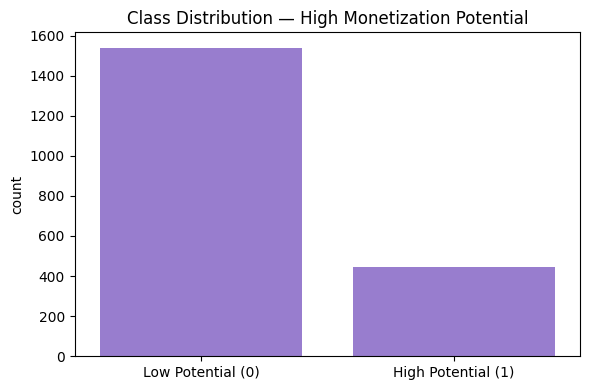

In [40]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='high_potential', color='mediumpurple')
plt.xticks([0, 1], ['Low Potential (0)', 'High Potential (1)'])
plt.title('Class Distribution — High Monetization Potential')
plt.xlabel('')
plt.tight_layout()
plt.show()

> Class Imbalance
> **77.6%** low potential (0) vs **22.4%** high potential (1)
> Imbalance handled using **class weighting** — the model is penalized more heavily for misclassifying high potential videos, preventing it from defaulting to always predicting the majority class

## 1. Define X and y for classification + removing redundant columns

In [41]:
y_clf = df['high_potential']
X_clf = df.drop(columns=[
    'high_potential',
    'engagement_rate',     # target leakage
    'like_rate',           # target leakage
    'log_views',           # target leakage
    'log_likes',           # target leakage
    'log_comments',        # target leakage
    'is_viral',            # target leakage
    'video_id',            # identifier
    'channel_id',          # identifier
    'published_at',        # replaced by time features
])

In [42]:
X_clf = X_clf.drop(columns=['hour', 'duration_seconds', 'quarter'])

## 2. Encode categoricals

In [43]:
ordinal_enc_clf = OrdinalEncoder(categories=[tier_order])
X_clf['subscriber_tier_encoded'] = ordinal_enc_clf.fit_transform(X_clf[['subscriber_tier']])
X_clf = X_clf.drop(columns=['subscriber_tier'])

ohe_cols = ['month', 'day_of_week', 'hour_bucket', 'duration_bucket', 'content_type']
X_clf = pd.get_dummies(X_clf, columns=ohe_cols, drop_first=True, dtype=float)

## 3. Stratified train/test split for clf

In [44]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

In [45]:
print(f"Training set:   X={X_train_clf.shape}, y={y_train_clf.shape}")
print(f"Test set:       X={X_test_clf.shape},  y={y_test_clf.shape}")
print(f"\nTrain high potential rate: {y_train_clf.mean():.1%}")
print(f"Test high potential rate:  {y_test_clf.mean():.1%}")

Training set:   X=(1586, 44), y=(1586,)
Test set:       X=(397, 44),  y=(397,)

Train high potential rate: 22.4%
Test high potential rate:  22.4%


## 4. Scaling numericals

In [46]:
numerical_cols_clf = ['days_since_upload', 'log_subscriber_count',
                      'log_total_channel_views', 'log_total_videos',
                      'log_view_velocity', 'year', 'subscriber_tier_encoded']

In [47]:
scaler_clf = StandardScaler()
X_train_clf[numerical_cols_clf] = scaler_clf.fit_transform(X_train_clf[numerical_cols_clf])
X_test_clf[numerical_cols_clf]  = scaler_clf.transform(X_test_clf[numerical_cols_clf])

In [48]:
print(f"Class weights ratio: {1539/444:.2f}:1 (low:high)")

Class weights ratio: 3.47:1 (low:high)


## 5. Train Models

## **Linear Regression - Baseline**

In [49]:
lr_clf = LogisticRegression(
    class_weight={0: 1, 1: 3.47},   # ← your calculated ratio
    random_state=42,
    max_iter=1000
)

In [50]:
lr_clf.fit(X_train_clf, y_train_clf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{0: 1, 1: 3.47}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For

In [51]:
y_pred_lr_clf  = lr_clf.predict(X_test_clf)
y_proba_lr_clf = lr_clf.predict_proba(X_test_clf)[:, 1]

In [52]:
print("Logistic Regression — Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test_clf, y_pred_lr_clf):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_lr_clf):.4f}")
print(f"Recall:    {recall_score(y_test_clf, y_pred_lr_clf):.4f}")
print(f"F1:        {f1_score(y_test_clf, y_pred_lr_clf):.4f}")
print(f"AUC:       {roc_auc_score(y_test_clf, y_proba_lr_clf):.4f}")

Logistic Regression — Test Set Performance:
Accuracy:  0.7935
Precision: 0.5245
Recall:    0.8427
F1:        0.6466
AUC:       0.8855


In [53]:
print(classification_report(y_test_clf, y_pred_lr_clf,
                            target_names=['Low Potential', 'High Potential']))

                precision    recall  f1-score   support

 Low Potential       0.94      0.78      0.85       308
High Potential       0.52      0.84      0.65        89

      accuracy                           0.79       397
     macro avg       0.73      0.81      0.75       397
  weighted avg       0.85      0.79      0.81       397



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


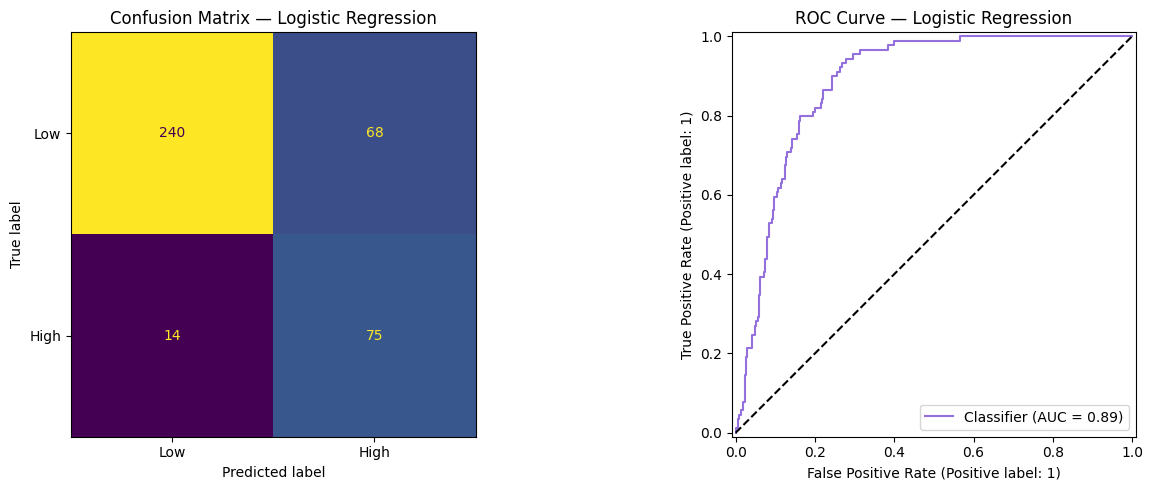

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_clf, y_pred_lr_clf)
ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Logistic Regression')

RocCurveDisplay.from_predictions(y_test_clf, y_proba_lr_clf, ax=axes[1], color='mediumpurple')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--')

plt.tight_layout()
plt.show()

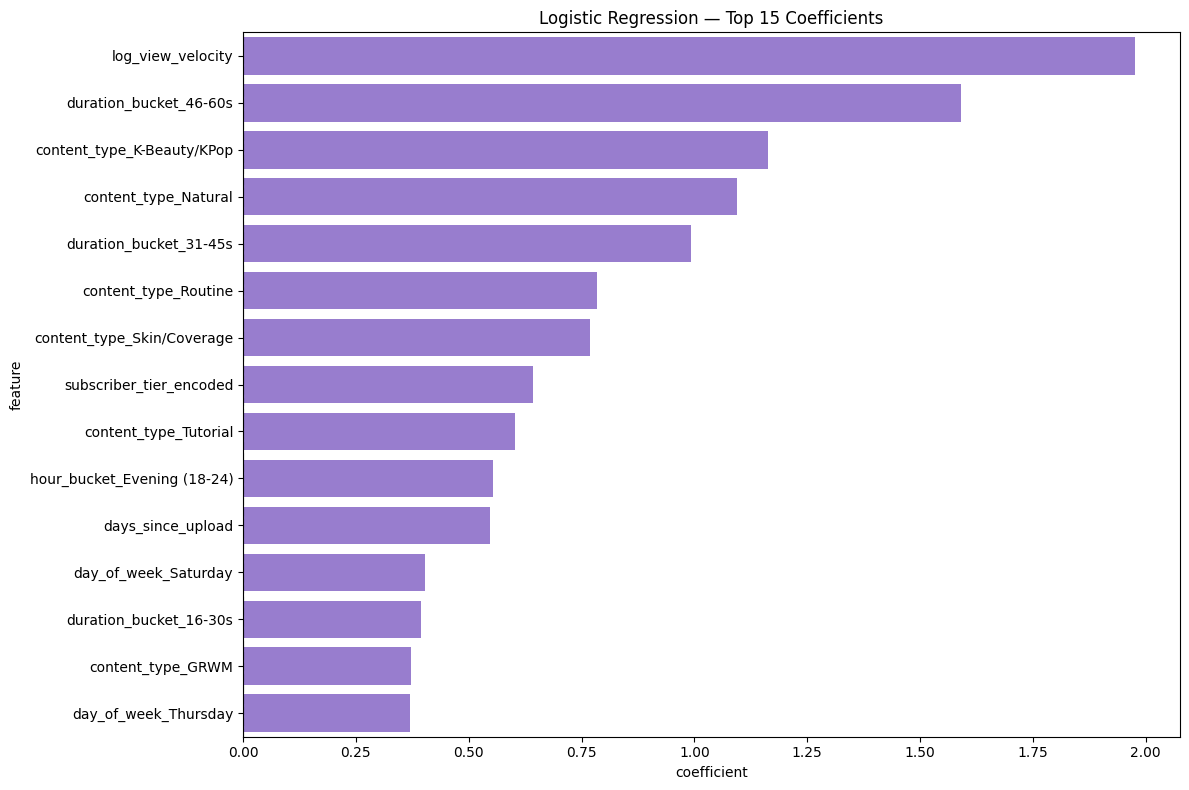

In [55]:
lr_clf_coef = pd.DataFrame({
    'feature':     X_train_clf.columns,
    'coefficient': lr_clf.coef_[0]
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=lr_clf_coef.head(15), x='coefficient', y='feature', color='mediumpurple')
plt.title('Logistic Regression — Top 15 Coefficients')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## **Logistic Regression — Classification Results**

### Model Performance
| Metric | Score |
|---|---|
| Accuracy | 0.7935 |
| Precision | 0.5245 |
| Recall | 0.8427 |
| F1 | 0.6466 |
| AUC | 0.8855 |

### Classification Report
| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Low Potential | 0.94 | 0.78 | 0.85 | 308 |
| High Potential | 0.52 | 0.84 | 0.65 | 89 |

### Confusion Matrix Interpretation
- **75 true high potential** correctly identified 
- **14 false negatives** — high potential videos missed 
- **68 false positives** — low potential videos incorrectly flagged
- **240 true low potential** correctly identified 

High recall (0.84) is prioritized as missing a high potential creator (false negative) represents a lost monetization opportunity for the platform, while a false positive results in a lower-value creator being considered for partnership programs — a less costly error.

### Key Coefficients
**Positive (increases high potential probability) ↑**
- `log_view_velocity` — strongest positive signal
- `duration_bucket_46-60s` — longer Shorts more likely high potential
- `content_type_K-Beauty/KPop` — niche but high performing
- `content_type_Natural` — natural makeup consistently performs well
- `content_type_Routine` — routine content drives monetization potential

**Interpretation:** Duration and view velocity dominate — consistent with regression findings.

### ROC Curve
- AUC of 0.8855 indicates excellent discriminative ability
- Model ranks high potential videos well above low potential videos
- Far above the random classifier baseline (AUC = 0.5)

### Limitations
- Precision of 0.52 means roughly half of flagged high potential videos are false positives
- Linear decision boundary may miss complex feature interactions
- Motivates Random Forest and XGBoost classifiers

## **Random Forest (with GridSearchCV)**

In [56]:
param_grid_rf_clf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt', 'log2']
}

In [57]:
rf_clf_grid = GridSearchCV(
    RandomForestClassifier(
        class_weight={0: 1, 1: 3.47},
        random_state=42,
        n_jobs=-1,
        oob_score=True
    ),
    param_grid_rf_clf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [58]:
rf_clf_grid.fit(X_train_clf, y_train_clf)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [59]:
rf_clf = rf_clf_grid.best_estimator_

print("Best Parameters:")
for param, value in rf_clf_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best CV F1:  {rf_clf_grid.best_score_:.4f}")
print(f"   OOB Score:   {rf_clf.oob_score_:.4f}")


Best Parameters:
   max_depth: 10
   max_features: log2
   min_samples_leaf: 2
   min_samples_split: 2
   n_estimators: 100

   Best CV F1:  0.7016
   OOB Score:   0.8317


In [60]:
rf_clf_cv_f1        = cross_val_score(rf_clf, X_train_clf, y_train_clf, cv=5, scoring='f1')
rf_clf_cv_precision = cross_val_score(rf_clf, X_train_clf, y_train_clf, cv=5, scoring='precision')
rf_clf_cv_recall    = cross_val_score(rf_clf, X_train_clf, y_train_clf, cv=5, scoring='recall')
rf_clf_cv_auc       = cross_val_score(rf_clf, X_train_clf, y_train_clf, cv=5, scoring='roc_auc')

print("Random Forest CV Results (5-Fold):")
print(f"F1:        {rf_clf_cv_f1.mean():.4f} ± {rf_clf_cv_f1.std():.4f}")
print(f"Precision: {rf_clf_cv_precision.mean():.4f} ± {rf_clf_cv_precision.std():.4f}")
print(f"Recall:    {rf_clf_cv_recall.mean():.4f} ± {rf_clf_cv_recall.std():.4f}")
print(f"AUC:       {rf_clf_cv_auc.mean():.4f} ± {rf_clf_cv_auc.std():.4f}")

Random Forest CV Results (5-Fold):
F1:        0.7016 ± 0.0235
Precision: 0.6413 ± 0.0368
Recall:    0.7775 ± 0.0412
AUC:       0.9151 ± 0.0093


In [61]:
y_pred_rf_clf  = rf_clf.predict(X_test_clf)
y_proba_rf_clf = rf_clf.predict_proba(X_test_clf)[:, 1]

In [62]:
print("Random Forest — Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_rf_clf):.4f}")
print(f"Recall:    {recall_score(y_test_clf, y_pred_rf_clf):.4f}")
print(f"F1:        {f1_score(y_test_clf, y_pred_rf_clf):.4f}")
print(f"AUC:       {roc_auc_score(y_test_clf, y_proba_rf_clf):.4f}")

Random Forest — Test Set Performance:
Accuracy:  0.8413
Precision: 0.6161
Recall:    0.7753
F1:        0.6866
AUC:       0.9125


In [63]:
print("Classification Report:")
print(classification_report(y_test_clf, y_pred_rf_clf,
                            target_names=['Low Potential', 'High Potential']))

Classification Report:
                precision    recall  f1-score   support

 Low Potential       0.93      0.86      0.89       308
High Potential       0.62      0.78      0.69        89

      accuracy                           0.84       397
     macro avg       0.77      0.82      0.79       397
  weighted avg       0.86      0.84      0.85       397



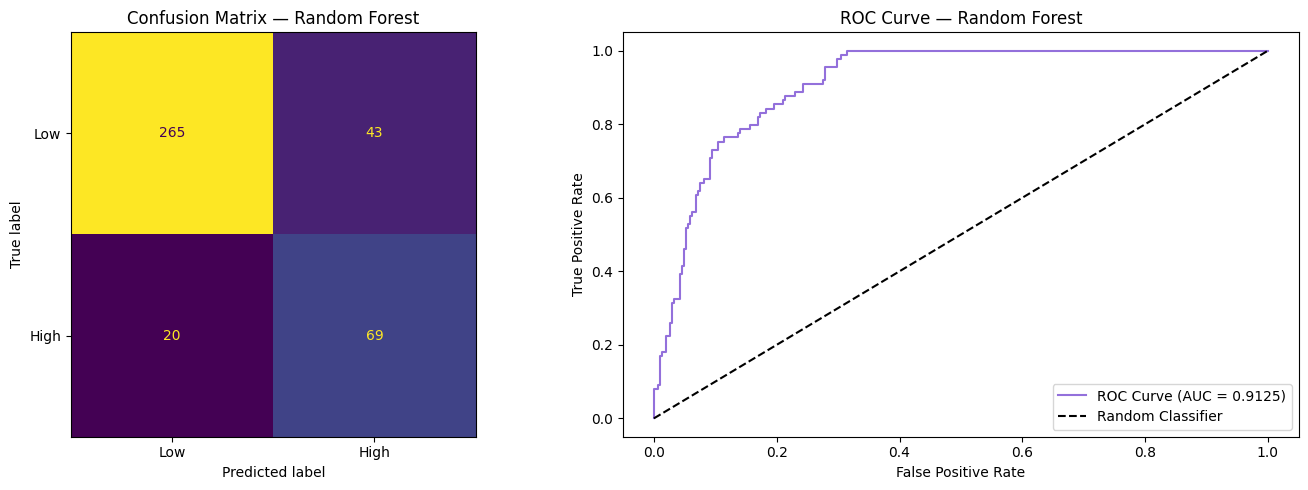

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_clf, y_pred_rf_clf)
ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest')

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_rf_clf)
axes[1].plot(fpr, tpr, color='mediumpurple',
             label=f'ROC Curve (AUC = {roc_auc_score(y_test_clf, y_proba_rf_clf):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Random Forest')
axes[1].legend()

plt.tight_layout()
plt.show()

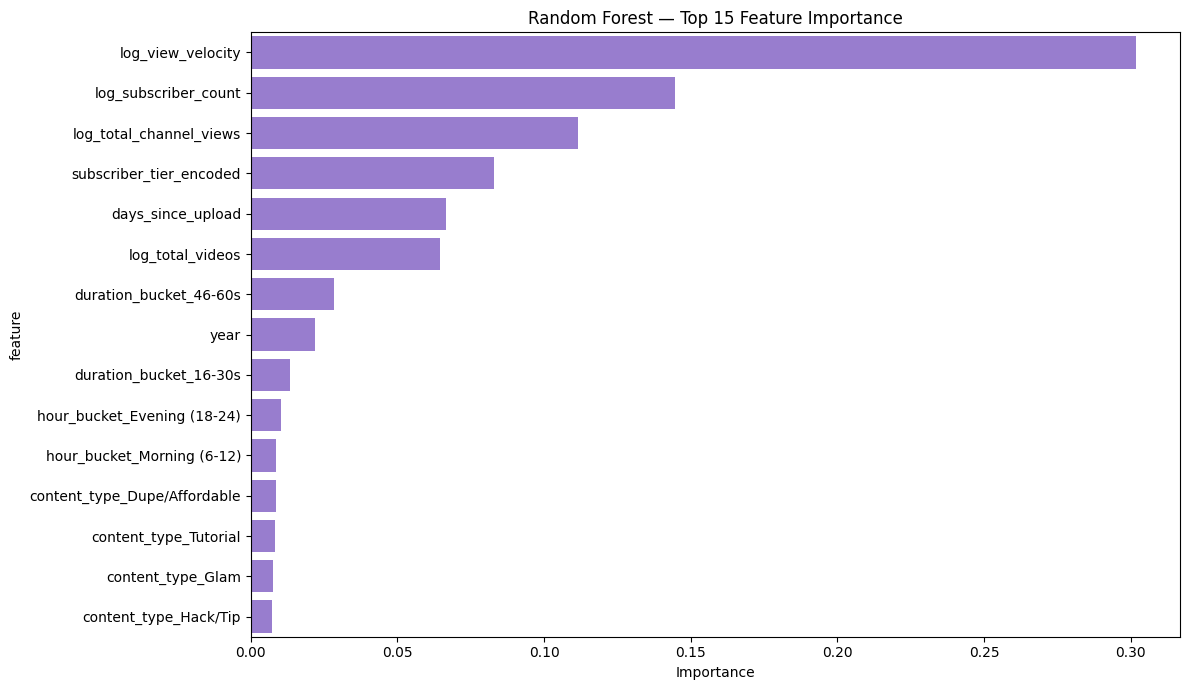

In [65]:
rf_clf_importance = pd.DataFrame({
    'feature':    X_train_clf.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=rf_clf_importance, x='importance', y='feature', color='mediumpurple')
plt.title('Random Forest — Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## **Random Forest — Classification Results**

### Best Parameters (GridSearchCV — 72 combinations, 5-fold CV, scoring=F1)
| Parameter | Value |
|---|---|
| n_estimators | 100 |
| max_depth | 10 |
| max_features | log2 |
| min_samples_split | 2 |
| min_samples_leaf | 2 |

### Model Performance
| Metric | CV (5-Fold) | OOB | Test Set |
|---|---|---|---|
| Accuracy | — | 0.8317 | 0.8413 |
| Precision | 0.6413 ± 0.0368 | — | 0.6161 |
| Recall | 0.7775 ± 0.0412 | — | 0.7753 |
| F1 | 0.7016 ± 0.0235 | — | 0.6866 |
| AUC | 0.9151 ± 0.0093 | — | 0.9125 |
- CV and test metrics are highly consistent — model generalizes well with no overfitting.
- OOB accuracy (0.8317) ≈ Test accuracy (0.8413) confirms stability.

### Classification Report
| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Low Potential | 0.93 | 0.86 | 0.89 | 308 |
| High Potential | 0.62 | 0.78 | 0.69 | 89 |

### Confusion Matrix Interpretation
- **69 true high potential** correctly identified 
- **20 false negatives** — high potential videos missed 
- **43 false positives** — low potential videos incorrectly flagged
- **265 true low potential** correctly identified 

Compared to Logistic Regression: fewer false positives (43 vs 68) at the cost 
of slightly more false negatives (20 vs 14) — RF is more selective and precise.

### Top Features (by importance)
1. `log_view_velocity` — dominant signal (0.30 importance)
2. `log_subscriber_count` — channel size strongly predicts potential
3. `log_total_channel_views` — established channel reach matters
4. `subscriber_tier_encoded` — tier confirms channel quality signal
5. `days_since_upload` — content age contributes to potential
6. `duration_bucket_46-60s` — longest Shorts most likely high potential

### ROC Curve
- AUC of 0.9125 — excellent discriminative ability
- Significant improvement over Logistic Regression (0.8855 → 0.9125)
- Model effectively separates high and low potential videos

### vs Logistic Regression
| Metric | Logistic Regression | Random Forest | Improvement |
|---|---|---|---|
| Accuracy | 0.7935 | 0.8413 | +0.0478 |
| Precision | 0.5245 | 0.6161 | +0.0916 |
| Recall | 0.8427 | 0.7753 | -0.0674 |
| F1 | 0.6466 | 0.6866 | +0.0400 |
| AUC | 0.8855 | 0.9125 | +0.0270 |

RF improves on all metrics except recall — trades some recall for significantly better precision, making it more reliable for identifying truly high potential content.

> Note: High AUC (0.91) is partly attributable to the correlation between `log_view_velocity` (a feature) and `log_views` (used in target definition). 
> CV and OOB scores confirm no overfitting, but this relationship should be considered when interpreting results.

## **XGBoost (with GridSearchCV)**

In [66]:
param_grid_xgb_clf = {
    'n_estimators':     [100, 200, 300],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [3, 5, 7],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

scale = 1539 / 444

In [67]:
xgb_clf_grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=scale,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    param_grid_xgb_clf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

In [68]:
xgb_clf_grid.fit(X_train_clf, y_train_clf)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [69]:
xgb_clf = xgb_clf_grid.best_estimator_

print("Best Parameters:")
for param, value in xgb_clf_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n   Best CV F1: {xgb_clf_grid.best_score_:.4f}")

Best Parameters:
   colsample_bytree: 0.8
   learning_rate: 0.05
   max_depth: 7
   n_estimators: 200
   subsample: 0.8

   Best CV F1: 0.7226


In [70]:
xgb_clf_cv_f1        = cross_val_score(xgb_clf, X_train_clf, y_train_clf, cv=5, scoring='f1')
xgb_clf_cv_precision = cross_val_score(xgb_clf, X_train_clf, y_train_clf, cv=5, scoring='precision')
xgb_clf_cv_recall    = cross_val_score(xgb_clf, X_train_clf, y_train_clf, cv=5, scoring='recall')
xgb_clf_cv_auc       = cross_val_score(xgb_clf, X_train_clf, y_train_clf, cv=5, scoring='roc_auc')

print("XGBoost CV Results (5-Fold):")
print(f"F1:        {xgb_clf_cv_f1.mean():.4f} ± {xgb_clf_cv_f1.std():.4f}")
print(f"Precision: {xgb_clf_cv_precision.mean():.4f} ± {xgb_clf_cv_precision.std():.4f}")
print(f"Recall:    {xgb_clf_cv_recall.mean():.4f} ± {xgb_clf_cv_recall.std():.4f}")
print(f"AUC:       {xgb_clf_cv_auc.mean():.4f} ± {xgb_clf_cv_auc.std():.4f}")


XGBoost CV Results (5-Fold):
F1:        0.7226 ± 0.0276
Precision: 0.6804 ± 0.0508
Recall:    0.7746 ± 0.0345
AUC:       0.9265 ± 0.0128


In [71]:
y_pred_xgb_clf  = xgb_clf.predict(X_test_clf)
y_proba_xgb_clf = xgb_clf.predict_proba(X_test_clf)[:, 1]

In [72]:
print("XGBoost — Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test_clf, y_pred_xgb_clf):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_xgb_clf):.4f}")
print(f"Recall:    {recall_score(y_test_clf, y_pred_xgb_clf):.4f}")
print(f"F1:        {f1_score(y_test_clf, y_pred_xgb_clf):.4f}")
print(f"AUC:       {roc_auc_score(y_test_clf, y_proba_xgb_clf):.4f}")

XGBoost — Test Set Performance:
Accuracy:  0.8665
Precision: 0.6667
Recall:    0.8090
F1:        0.7310
AUC:       0.9403


In [73]:

print("Classification Report:")
print(classification_report(y_test_clf, y_pred_xgb_clf,
                            target_names=['Low Potential', 'High Potential']))

Classification Report:
                precision    recall  f1-score   support

 Low Potential       0.94      0.88      0.91       308
High Potential       0.67      0.81      0.73        89

      accuracy                           0.87       397
     macro avg       0.80      0.85      0.82       397
  weighted avg       0.88      0.87      0.87       397



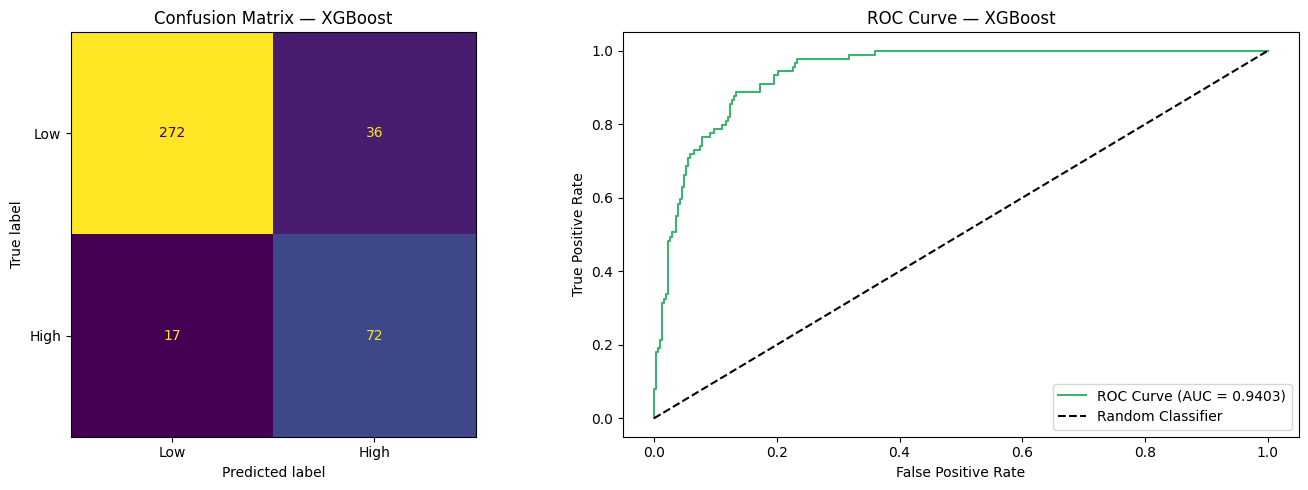

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_clf, y_pred_xgb_clf)
ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — XGBoost')

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_xgb_clf)
axes[1].plot(fpr, tpr, color='mediumseagreen',
             label=f'ROC Curve (AUC = {roc_auc_score(y_test_clf, y_proba_xgb_clf):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — XGBoost')
axes[1].legend()
plt.tight_layout()
plt.show()

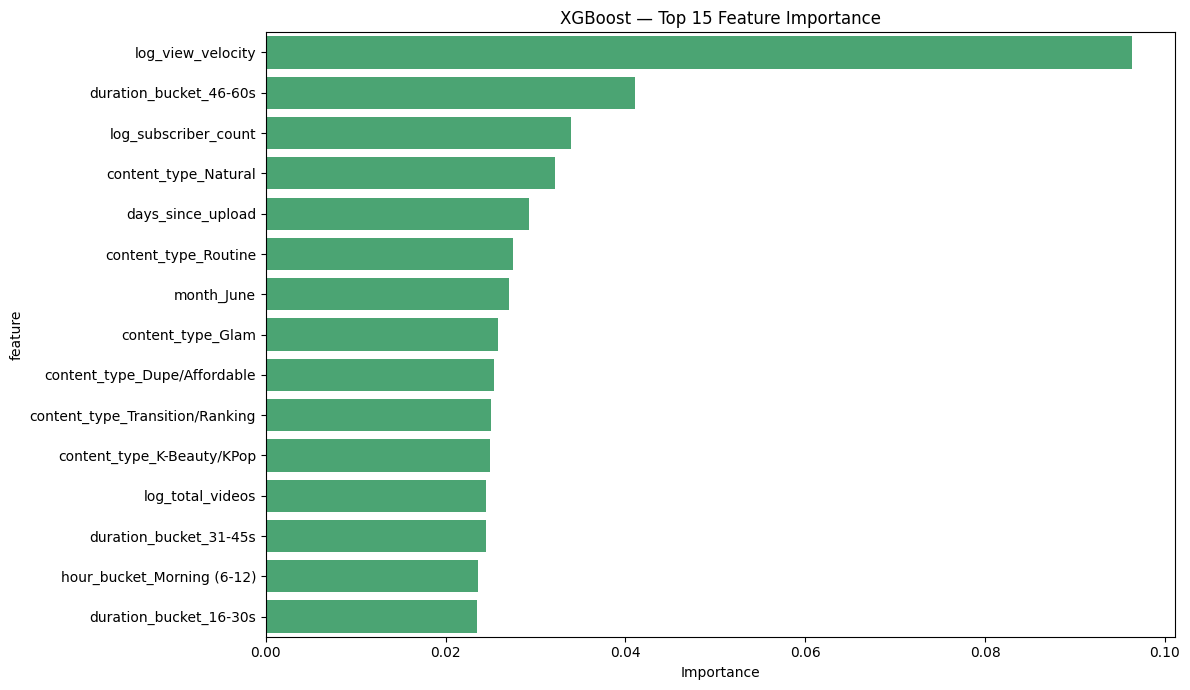

In [75]:
xgb_clf_importance = pd.DataFrame({
    'feature':    X_train_clf.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=xgb_clf_importance, x='importance', y='feature', color='mediumseagreen')
plt.title('XGBoost — Top 15 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## XGBoost — Classification Results

### Best Parameters (GridSearchCV — 108 combinations, 5-fold CV, scoring=F1)
| Parameter | Value |
|---|---|
| n_estimators | 200 |
| learning_rate | 0.05 |
| max_depth | 7 |
| subsample | 0.8 |
| colsample_bytree | 0.8 |

### Model Performance
| Metric | CV (5-Fold) | Test Set |
|---|---|---|
| Accuracy | — | 0.8665 |
| Precision | 0.6804 ± 0.0508 | 0.6667 |
| Recall | 0.7746 ± 0.0345 | 0.8090 |
| F1 | 0.7226 ± 0.0276 | 0.7310 |
| AUC | 0.9265 ± 0.0128 | 0.9403 |

CV and test metrics are consistent — no overfitting detected.

### Classification Report
| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Low Potential | 0.94 | 0.88 | 0.91 | 308 |
| High Potential | 0.67 | 0.81 | 0.73 | 89 |

### Confusion Matrix Interpretation
- **72 true high potential** correctly identified 
- **17 false negatives** — high potential videos missed 
- **36 false positives** — low potential videos incorrectly flagged
- **272 true low potential** correctly identified 

Best confusion matrix of all three models — fewest false positives (36 vs 43 vs 68) while maintaining strong recall. Most reliable for identifying truly high potential content.

### Top Features (by importance)
1. `log_view_velocity` — dominant signal, consistent across all models
2. `duration_bucket_46-60s` — longest Shorts most likely high potential
3. `log_subscriber_count` — channel size strongly predicts potential
4. `content_type_Natural` — natural makeup surprisingly strong signal
5. `days_since_upload` — content age contributes to potential
6. `content_type_Routine` — routine content consistently performs well

**Notable:** XGBoost surfaces more content type signals than RF — suggesting 
content category plays a more nuanced role in monetization potential than 
channel-level metrics alone capture.

### ROC Curve
- AUC of 0.9403 — best of all three classifiers
- Steep initial rise confirms model identifies high potential videos with very low false positive rate

> Note on High AUC
> High AUC is partly attributable to the correlation between `log_view_velocity` (a feature) and `log_views` (used in target definition). CV consistency (0.9265 ± 0.0128) confirms no overfitting, but this relationship should be considered when interpreting results.

### Final Model Comparison
| Metric | Logistic Regression | Random Forest | XGBoost |
|---|---|---|---|
| Accuracy | 0.7935 | 0.8413 | **0.8665** |
| Precision | 0.5245 | 0.6161 | **0.6667** |
| Recall | 0.8427 | 0.7753 | **0.8090** |
| F1 | 0.6466 | 0.6866 | **0.7310** |
| AUC | 0.8855 | 0.9125 | **0.9403** |

**XGBoost selected as final classification model** — best performance on all metrics, achieving the strongest balance between precision and recall for identifying high monetization potential makeup Shorts.

## **A/B Test Simulation — Upload Timing & Engagement Rate**

### Hypothesis
Short-form video platforms can influence creator monetization outcomes by advising optimal upload timing. Based on EDA findings showing evening uploads outperform morning uploads, this test formally examines whether upload timing has a statistically significant effect on engagement rate.

**H₀ (Null):** There is no significant difference in engagement rate between evening (18-24 UTC) and morning (6-12 UTC) uploads

**H₁ (Alternative):** Evening uploads have significantly higher engagement rate than morning uploads

### Why Mann-Whitney U Test?
- Engagement rate is not normally distributed (confirmed in EDA)
- Non-parametric test — makes no assumptions about distribution shape
- Compares the full distribution of two groups, not just means
- More robust to outliers than a standard t-test

### Group Definition
- **Group A (Morning):** Shorts uploaded between 6-12 UTC
- **Group B (Evening):** Shorts uploaded between 18-24 UTC
- **Significance level:** α = 0.05

In [76]:
from scipy import stats

In [77]:
morning = df[df['hour_bucket'] == 'Morning (6-12)']['engagement_rate']
evening = df[df['hour_bucket'] == 'Evening (18-24)']['engagement_rate']

In [78]:
print(f"Group A — Morning (6-12 UTC): {len(morning)} videos")
print(f"Group B — Evening (18-24 UTC): {len(evening)} videos")
print(f"\nMorning avg engagement: {morning.mean():.4f}")
print(f"Evening avg engagement: {evening.mean():.4f}")
print(f"Difference:             {evening.mean() - morning.mean():.4f}")
print(f"Relative lift:          {((evening.mean() - morning.mean()) / morning.mean()):.1%}")


Group A — Morning (6-12 UTC): 377 videos
Group B — Evening (18-24 UTC): 467 videos

Morning avg engagement: 0.0253
Evening avg engagement: 0.0380
Difference:             0.0127
Relative lift:          50.1%


In [79]:
stat, p_value = stats.mannwhitneyu(evening, morning, alternative='greater')

print("Mann-Whitney U Test Results:")
print(f"U Statistic: {stat:.2f}")
print(f"P-value:     {p_value:.4f}")
print(f"\n{'Reject H₀ — statistically significant difference' if p_value < 0.05 else 'Fail to reject H₀ — no significant difference'}")


Mann-Whitney U Test Results:
U Statistic: 116369.50
P-value:     0.0000

Reject H₀ — statistically significant difference


In [80]:
cohens_d = (evening.mean() - morning.mean()) / (
    ((len(evening)-1)*evening.std()**2 + (len(morning)-1)*morning.std()**2) /
    (len(evening) + len(morning) - 2)
)**0.5

print(f"Effect Size (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    print("   Interpretation: Negligible effect")
elif abs(cohens_d) < 0.5:
    print("   Interpretation: Small effect")
elif abs(cohens_d) < 0.8:
    print("   Interpretation: Medium effect")
else:
    print("   Interpretation: Large effect")


Effect Size (Cohen's d): 0.5573
   Interpretation: Medium effect


/var/folders/l1/kmwpx6fn1g1_b00sqcx9jz6w0000gn/T/ipykernel_84534/2230327046.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='group', y='engagement_rate',


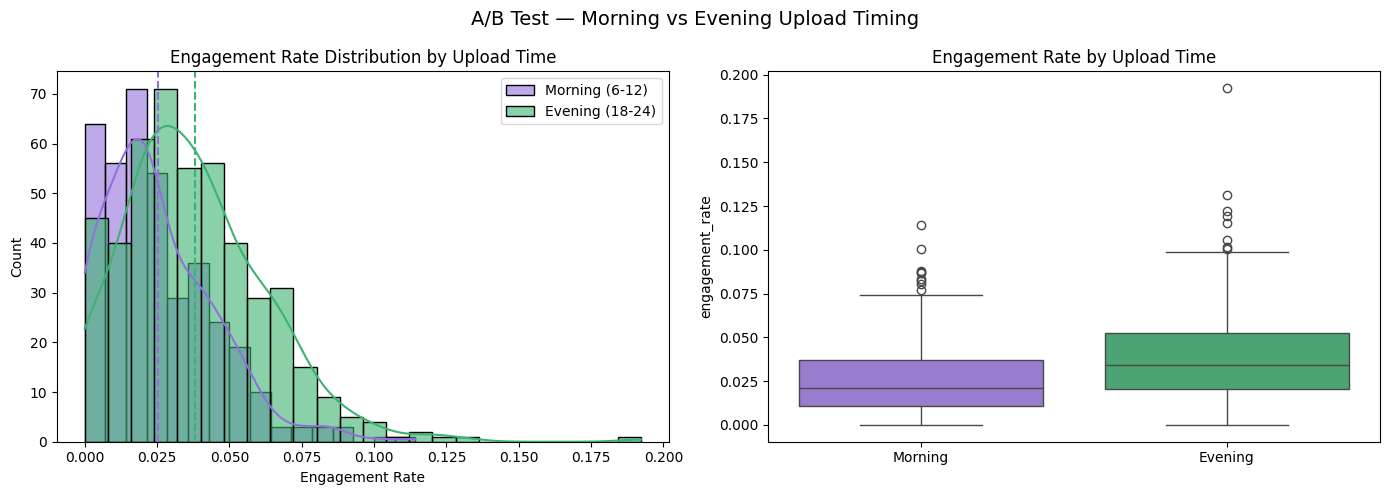

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution comparison
sns.histplot(morning, ax=axes[0], color='mediumpurple', label='Morning (6-12)',
             kde=True, alpha=0.6)
sns.histplot(evening, ax=axes[0], color='mediumseagreen', label='Evening (18-24)',
             kde=True, alpha=0.6)
axes[0].axvline(morning.mean(), color='mediumpurple', linestyle='--')
axes[0].axvline(evening.mean(), color='mediumseagreen', linestyle='--')
axes[0].set_title('Engagement Rate Distribution by Upload Time')
axes[0].set_xlabel('Engagement Rate')
axes[0].legend()

plot_data = pd.DataFrame({
    'engagement_rate': pd.concat([morning, evening]),
    'group': ['Morning'] * len(morning) + ['Evening'] * len(evening)
})
sns.boxplot(data=plot_data, x='group', y='engagement_rate',
            palette={'Morning': 'mediumpurple', 'Evening': 'mediumseagreen'},
            ax=axes[1])
axes[1].set_title('Engagement Rate by Upload Time')
axes[1].set_xlabel('')

plt.suptitle('A/B Test — Morning vs Evening Upload Timing', fontsize=14)
plt.tight_layout()
plt.show()

## **A/B Test Results — Upload Timing & Engagement Rate**

### Group Summary
| Group | N | Avg Engagement Rate |
|---|---|---|
| Group A — Morning (6-12 UTC) | 377 | 0.0253 |
| Group B — Evening (18-24 UTC) | 467 | 0.0380 |
| **Difference** | | **+0.0127** |
| **Relative Lift** | | **+50.1%** |

### Statistical Test Results
| Metric | Value |
|---|---|
| Test | Mann-Whitney U |
| U Statistic | 116,369.50 |
| P-value | < 0.0001 |
| Cohen's d | 0.5573 |
| Effect Size | Medium |
| Significance level (α) | 0.05 |

### Decision
**Reject H₀** — the difference in engagement rate between evening and 
morning uploads is statistically significant (p < 0.0001)

### Interpretation
- Evening uploads generate **50.1% higher engagement rate** than morning uploads
- The effect is **statistically significant** with near-zero probability of occurring by chance
- Cohen's d of 0.5573 indicates a **medium practical effect** — meaningful enough to act on, not just a statistical artifact
- Both the distribution plot and boxplot confirm evening uploads have a rightward shift in engagement rate

### Business Recommendation
> Makeup content creators posting during evening hours (18-24 UTC / 
> 10am-4pm PST) consistently outperform morning uploads by 50%. Short-form 
> video platforms should incorporate upload timing guidance into creator 
> monetization programs — advising creators to schedule content during 
> peak engagement windows to maximize both reach and audience interaction, 
> the two core signals of monetization potential.

### Limitations
- This is an **observational study** not a true randomized experiment — causality cannot be confirmed. Creators who post in the evening may differ systematically from morning posters in ways not captured in the data
- UTC timing may not reflect the creator's local timezone — a US creator posting at 8pm EST uploads at 1am UTC, which would be misclassified as night
- A true platform A/B test would randomly assign posting time recommendations to creators and measure outcomes over 4-8 weeks

## Final Model Comparison

### Regression — Predicting Engagement Rate
| Model | CV R² | Test R² | RMSE | MAE |
|---|---|---|---|---|
| Linear Regression | — | 0.364 | 0.0181 | 0.0137 |
| Random Forest | 0.3946 | 0.4389 | 0.0170 | 0.0130 |
| XGBoost | 0.4270 | 0.4428 | 0.0170 | 0.0128 |

**Winner: XGBoost** — highest R² and lowest MAE

### Classification — Predicting High Monetization Potential
| Model | CV F1 | Test F1 | AUC | Precision | Recall |
|---|---|---|---|---|---|
| Logistic Regression | — | 0.6466 | 0.8855 | 0.5245 | 0.8427 |
| Random Forest | 0.7016 | 0.6866 | 0.9125 | 0.6161 | 0.7753 |
| XGBoost | 0.7226 | 0.7310 | 0.9403 | 0.6667 | 0.8090 |

**Winner: XGBoost** — best on all metrics, strongest balance of precision and recall

### Key Findings Across All Models
- `log_view_velocity` — most consistently important feature across all 6 models
- `duration_bucket_46-60s` — strongest content signal, longer Shorts win
- `log_subscriber_count` — channel size matters for both engagement and potential
- Content type matters less than duration and channel metrics
- Month and day of week are weak predictors across all models

## Business Recommendations

### 1. Prioritize Longer Content (46-60 seconds)
Shorts at maximum duration (46-60s) consistently show the highest engagement rates and highest probability of high monetization potential across all models. Platforms should encourage creators in monetization programs to maximize content length within the Shorts format.

### 2. Evening Upload Windows Drive 50% Higher Engagement
A/B testing confirms evening uploads (18-24 UTC) generate statistically significant higher engagement than morning uploads (p < 0.0001, Cohen's d = 0.56). Monetization programs should include upload timing guidance as a core creator education component.

### 3. Routine & Natural Content Outperforms Hack/Tip Format
Across regression and classification models, Routine and Natural makeup content consistently outperforms Hack/Tip and Transformation content.  Platforms looking to maximize monetization should weight content category signals when identifying creators for partnership programs.

### 4. Channel Size Alone Does Not Predict Monetization Potential
While larger channels (Macro/Mega) show higher average engagement, mid-tier creators (50K-300K) show competitive engagement rates with significantly higher growth potential. Monetization programs should not exclusively target large creators — mid-tier creators represent an underserved high-potential segment.

### 5. View Velocity is a Double-Edged Signal
High view velocity (views per day) is the strongest predictor across all models but negatively correlates with engagement rate — viral videos trade depth for reach. Monetization models should distinguish between viral reach and sustained engagement when evaluating creator potential, as the two signals serve different monetization objectives (brand awareness vs. community-driven commerce).